In [1]:
import os
import pickle
import re
import warnings
import matplotlib.pyplot as plt
import cv2
import numpy as np
from keras_facenet import FaceNet
from sklearn.metrics.pairwise import cosine_similarity
from mtcnn import MTCNN

In [2]:
# load embedding model from keras-facenet
embedding_model = FaceNet()
detector = MTCNN()


# function for making embeddings from image
# def embeddings(image_path):
image_path = "images/tushar.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# print(img)

image_embedding = embedding_model.embeddings([img])
# print(image_embedding[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [3]:
# function to generate embeddings of an image
def image_to_embeddings(image_path):
    embedding_model = FaceNet()

    # load the image
    img = cv2.imread(image_path)
    # print(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # embeddings
    image_embedding = embedding_model.embeddings([img])
    return image_embedding[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
cosine similarity : 0.6502
faces matched


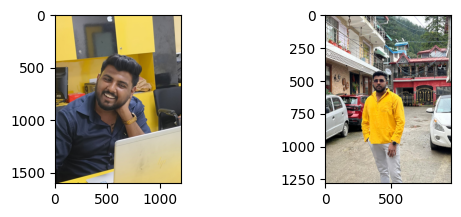

In [4]:
emb1 = image_to_embeddings('images/tushar.jpg')
img1 = cv2.imread('images/tushar.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

emb2 = image_to_embeddings('tushar1.jpg')
img2 = cv2.imread('tushar1.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

similarity = cosine_similarity([emb1], [emb2])[0][0]
print(f"cosine similarity : {similarity:.4f}")
if similarity >= 0.5:
    plt.subplot(2, 2, 1)
    plt.imshow(img1)

    plt.subplot(2, 2, 2)
    plt.imshow(img2)
    print("faces matched")
else:
    print("No match found")

In [5]:
embedding_model = FaceNet()
detector = MTCNN()

known_faces_dir = r"C:\Users\tbaka\face_recognizer\employee"

known_faces = []
known_names = []

for filename in os.listdir(known_faces_dir):
    if filename.endswith((".jpg", ".png")):
        image_path = os.path.join(known_faces_dir, filename)
        img = cv2.imread(image_path)
        if img is None:
            print(f"could not find any image at {image_path}")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (160, 160))
        embedding = embedding_model.embeddings([img_resized])[0]
        names = re.sub(r'\d+','',os.path.splitext(filename)[0])
        known_faces.append(embedding)
        known_names.append(names)
        
print(f"Loaded {len(known_faces)} known faces.")
print(f"[INFO] Collected {len(known_faces)} embeddings for {len(set(known_names))} people")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Loaded 11 known faces.
[INFO] Collected 11 embeddings for 4 people


In [6]:
# Save embeddings + labels
embedding_file = "embeddings.pkl"
data = {"embeddings": known_faces, "labels": known_names}
with open(embedding_file, "wb") as f:
    pickle.dump(data, f)

In [7]:
len(known_names)

11

In [8]:
known_names

['kuldeep',
 'nagesh',
 'prashant_kumar',
 'tushar',
 'tushar',
 'tushar',
 'tushar',
 'tushar',
 'tushar',
 'tushar',
 'tushar']

In [8]:
# os.path.join('known_faces_dir', 'filename')

In [9]:
# import re
# for filename in os.listdir("all/"):
#     print(re.sub(r'\d+','',os.path.splitext(filename)[0]))
    

In [10]:
# # caputure only face in the image and convert that to embeddings for comparison
# # 1. Requirement :  previous embedded image should be a face image only otherwise not compatible to do the comparison

# cap = cv2.VideoCapture(0)

# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break

#     img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#     faces = detector.detect_faces(img_rgb)

#     for face in faces:
#         x, y, w, h = face['box']
#         x, y = max(0, x), max(0, y)
#         face_img = frame[y:y+h, x:x+w]
#         face_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
#         face_resized = cv2.resize(face_rgb, (160, 160))
#         face_resized = face_resized.astype('float32') / 255.0

#         # Get embedding
#         embedding = embedding_model.embeddings([face_resized])[0]

#         label = "Unauthorized"
#         if known_faces:
#             similarity = cosine_similarity([embedding], known_faces)[0]
#             best_idx = np.argmax(similarity)
#             best_similarity = similarity[best_idx]
#             if best_similarity >= 0.5:
#                 label = known_names[best_idx]

#         # Draw rectangle and label
#         cv2.rectangle(frame, (x-10, y-10), (x+w+10, y+h+10), (255, 0, 0), 2)
#         cv2.putText(frame, label, (x, y-15), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

#     cv2.imshow("Face Recognition", frame)

#     # Use waitKey(1) for real-time
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# cap.release()
# cv2.destroyAllWindows()

In [11]:
# # Read image
# img = cv2.imread("tushar1.jpg")
# img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [12]:
# plt.imshow(img_rgb)

In [13]:
# detector = MTCNN()
# faces = detector.detect_faces(img_rgb)

In [14]:
# detector = MTCNN()
# faces = detector.detect_faces(img_rgb)

# for i , face in enumerate(faces):
#     x, y, w, h = face['box']
#     x, y = max(0, x), max(0, y)
#     face_img = img[y : y+h, x : x+w ]


In [15]:
# plt.imshow(face_img)

In [16]:
# cv2.imwrite('tushar_cropped_face.jpg', face_img)

In [59]:
# Ask for person's name
person_name = input("Enter the person's name: ").strip()

# Initialize webcam and face detector
cap = cv2.VideoCapture(0)
detector = MTCNN()

count = 0
MAX_IMAGES = 20 # Number of face images to capture

print(f"[INFO] Starting capture for {person_name}. Look at the camera...")


Enter the person's name:  kuldeep


[INFO] Starting capture for kuldeep. Look at the camera...


In [60]:

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Detect faces
    faces = detector.detect_faces(frame)

    for face in faces:
        x, y, w, h = face['box']
        x, y = max(0, x), max(0, y)
        # Padding factor (percentage of face size)
        pad_x = int(w * 0.2)   # 20% of width
        pad_y = int(h * 0.2)   # 20% of height
        
        # Apply padding
        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(frame.shape[1], x + w + pad_x)
        y2 = min(frame.shape[0], y + h + pad_y)
        
        # Crop expanded face
        face_img = frame[y1:y2, x1:x2]
    
        
        # # Crop the face
        # face_img = frame[y:y+h+30, x:x+w+10]

        # Save only if we have a valid face crop
        if face_img.size > 0:
            face_resized = cv2.resize(face_img, (160, 160))  # FaceNet size
            count += 1
            file_path = os.path.join(known_faces_dir,f"{person_name}{count}.jpg")
            cv2.imwrite(file_path, face_resized)
            print(f"[SAVED] {file_path}")

        # Draw rectangle & counter on screen
        # cv2.rectangle(frame, (x1, y1), (x+w +30, y+h+30), (0, 255, 0), 2)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f"{person_name} - {count}/{MAX_IMAGES}", 
                    (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Show video stream
    cv2.imshow("Face Capture", frame)

    # Break if enough images captured
    if count >= MAX_IMAGES:
        print("[INFO] Capture complete!")
        break

    # Press 'q' to quit early
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep1.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep2.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep3.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep4.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep5.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep6.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep7.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep8.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep9.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep10.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep11.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep12.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep13.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep14.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep15.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kuldeep16.jpg
[SAVED] C:\Users\tbaka\face_recognizer\images\kul

In [9]:
# caputure entire image and convert the entire image to embedding and then doing the comparison for authentication
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # DETECT AND GET EMBEDDINGS
    embeddings = embedding_model.embeddings([img_rgb])

    for emb in embeddings:
        similarity = cosine_similarity([emb], known_faces)[0]
        best_match_idx = np.argmax(similarity)
        best_similarity = similarity[best_match_idx]

        if best_similarity >= 0.5:
            name = known_names[best_match_idx]
            label = f"{name} ({best_similarity:.2f})"
        else:
            label = "Unknown"

        # Draw a rectangle and label on it
        
        cv2.putText(frame, label, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow("Face Recognition", frame)


    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━

In [70]:
os.path.join(f"{person_name}{count}.jpg")

'kuldeep20.jpg'

In [10]:
import cv2
import pickle
import numpy as np
from keras_facenet import FaceNet
from sklearn.metrics.pairwise import cosine_similarity
from mtcnn import MTCNN
from collections import deque, Counter

# Load FaceNet and embeddings
embedder = FaceNet()
detector = MTCNN()

with open("embeddings.pkl", "rb") as f:
    data = pickle.load(f)

known_embeddings = np.array(data["embeddings"])
known_labels = np.array(data["labels"])

THRESHOLD = 0.7   # tune this between 0.55 - 0.7
VOTE_FRAMES = 10   # number of frames to keep for voting

# Queue to store last predictions
pred_queue = deque(maxlen=VOTE_FRAMES)

cap = cv2.VideoCapture(0)
print("[INFO] Starting real-time recognition...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    faces = detector.detect_faces(frame)
    label = "No Face"

    for face in faces:
        x, y, w, h = face['box']
        x, y = max(0, x), max(0, y)

        # Crop & preprocess
        face_img = frame[y:y+h, x:x+w]
        if face_img.size == 0:
            continue

        face_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
        face_resized = cv2.resize(face_rgb, (160, 160))
        face_resized = face_resized.astype("float32") / 255.0

        # Embedding
        embedding = embedder.embeddings([face_resized])[0]

        # Compare with known embeddings
        sims = cosine_similarity([embedding], known_embeddings)[0]
        best_idx = np.argmax(sims)
        best_score = sims[best_idx]

        if best_score > THRESHOLD:
            pred_label = known_labels[best_idx]
        else:
            pred_label = "Unauthorized"

        # Add prediction to queue
        pred_queue.append(pred_label)

        # Voting: choose the most common label in queue
        final_label = Counter(pred_queue).most_common(1)[0][0]

        # Draw rectangle & label
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, f"{final_label}", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.imshow("Face Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


[INFO] Starting real-time recognition...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━

In [24]:
images_path = 'cheetah.png'

In [25]:
img = cv2.imread(image_path)

In [42]:
detector = MTCNN()
embedding_model = FaceNet()

C:\Users\tbaka\AppData\Local\Temp\ipykernel_11636\1211420001.py:7: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


cheetah.png
GANDU.png
harris.png
kamal.png
nayan.png
prashant.jpg
reporter.png
rishabh.png
sumit.png
tushar1.jpg
tushar2.jpg
tushar3.jpg
tushar4.jpg
tushar5.jpg
tushar6.jpg


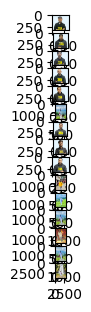

In [13]:
i = 0
for filename in os.listdir(r"C:\Users\tbaka\face_recognizer"):
    if filename.endswith((".jpg", ".png")):
        img = cv2.imread(filename)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(len(os.listdir(r"C:\Users\tbaka\face_recognizer")), 1, i + 1)
        plt.tight_layout()
        print(filename)
        i = i+1
        plt.imshow(img_rgb)
    #     faces = detector.detect_faces(img_rgb)

    # for face in faces:
    #     x, y, w, h = face['box']
    #     x, y = max(0, x), max(0, y)
    #     face_img = frame[y:y+h, x:x+w]
    #     face_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
    #     plt.imshow(face_rgb)